# MACHINE LEARNING - Clustering Project
**Etudiants** : Louis-Gabriel BROSSIER | Victor LOUX | Hoang-Triet NGUYEN

## Introduction
L'hiver approche, les soirées s'allongent, et notre backlog Steam ne va clairement pas se trier tout seul. On a donc besoin d'analyser un dataset de jeux et d'utiliser du clustering pour repérer les pépites parfaites pour hiberner intelligemment.

### Notre jeu de données
*   C'est quoi le dataset ?

Ce dataset a été créé en récupérant des données sur Steam et sur Steam Games Scraper, qui collecte des données à l'aide de l'API Steam et Steam Spy. Elle est à jour jusqu'à mars 2025. Ce dataset nous permet d'avoir une vue globale sur un grand nombre de features pour chacun des jeux du Steam Store.

*   Lister tous les features

 Voici toutes les features que nous avons en disposition : 
 - appid 
 - name 
 - release_date 
 - required_age 
 - price 
 - dlc_count 
 - metacritic_score 
 - achievements 
 - recommendations 
 - categories 
 - positive 
 - negative 
 - median_playtime_forever 
 - peak_ccu 
 - pct_pos_total

### Notre objectives


## Importation des librairies et du dataset

In [146]:
# Importation des librairies
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("./dataset/Steam_Games_2025.csv")
df.head()


,appid,name,release_date,required_age,price,dlc_count,metacritic_score,achievements,recommendations,categories,positive,negative,median_playtime_forever,peak_ccu,pct_pos_total,num_reviews_total
0,730,Counter-Strike 2,2012-08-21,0,0.00,1,0,1,4401572,"['Multi-player', 'Cross-Platform Multiplayer',...",7480813,1135108,5174,1212356,86,8632939
1,578080,PUBG: BATTLEGROUNDS,2017-12-21,0,0.00,0,0,37,1732007,"['Multi-player', 'PvP', 'Online PvP', 'Stats',...",1487960,1024436,0,616738,59,2513842
2,570,Dota 2,2013-07-09,0,0.00,2,90,0,14337,"['Multi-player', 'Co-op', 'Steam Trading Cards...",1998462,451338,898,555977,81,2452595
3,271590,Grand Theft Auto V Legacy,2015-04-13,17,0.00,0,96,77,1803063,"['Single-player', 'Multi-player', 'PvP', 'Onli...",1719950,250012,7101,117698,87,1803832
4,359550,Tom Clancy's Rainbow Six® Siege,2015-12-01,17,3.99,9,0,0,1165929,"['Single-player', 'Multi-player', 'PvP', 'Onli...",1152763,218446,2434,89916,84,1168020


## Prétraitement des données


In [147]:
## Supprimer 'appid' du dataset
if ('appid' in df.columns):
    df = df.drop(columns=['appid'])

## Supprimer les jeux sans recommandations
# df = df[df['metacritic_score'] > 0]
# df = df[df['recommendations'] > 500]
## Garder que 100 jeux avec le plus de recommandations et sort par 'recommendations'
df = df.nlargest(1000, 'recommendations').sort_values(by='recommendations', ascending=False)

## Supprimer 'positif' et 'negative' car redondant avec 'pct_pos_total'
df = df.drop(columns=['positive', 'negative', 'median_playtime_forever'])

## Transformer 'release_date' en Année de sortie et changer le nom de la colonne
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df = df.rename(columns={'release_date': 'release_year'})

## Extraire 'single_player' et 'multi_player' de la colonne 'categories'
def extract_category(df: pd.DataFrame, categories_name: str) -> int:
    return 1 if categories_name and df.find(categories_name) != -1 else 0
df['single_player'] = df['categories'].apply(extract_category, args=('Single-player',))
df['multi_player'] = df['categories'].apply(extract_category, args=('Multi-player',))
df = df.drop(columns=['categories'])

# Verifier les modifications
# Nombre d'échantillons et de features
print("Number of samples:", df.shape[0])
print("Number of features:", df.shape[1])


Number of samples: 1000
Number of features: 13


## Exploration des données

Features: ['release_year', 'required_age', 'price', 'dlc_count', 'metacritic_score', 'achievements', 'recommendations', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'single_player', 'multi_player']


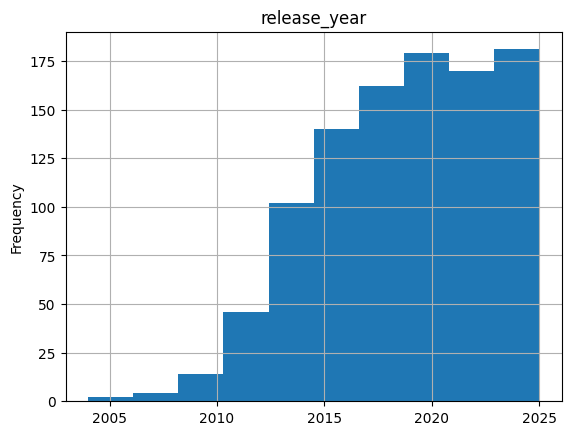

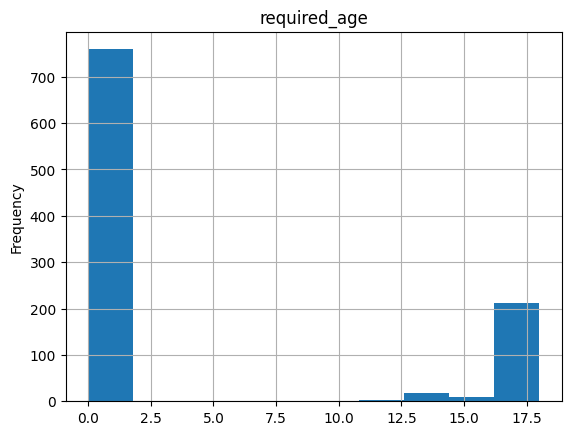

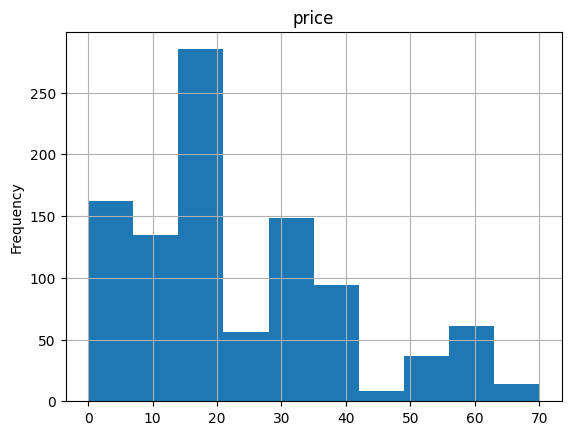

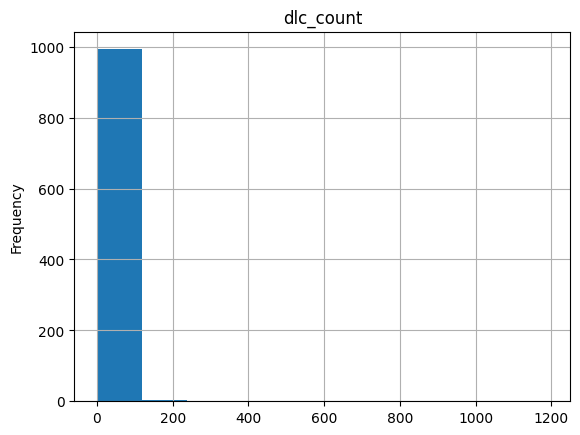

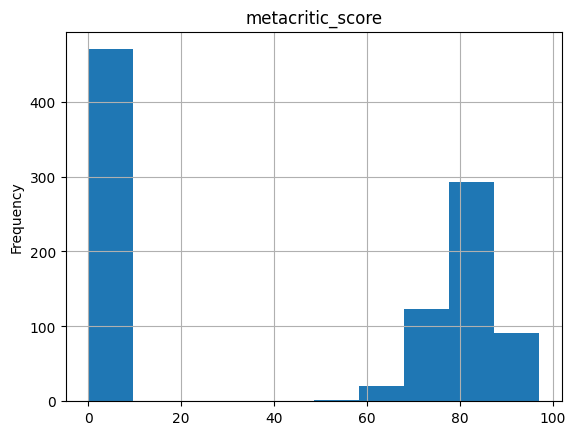

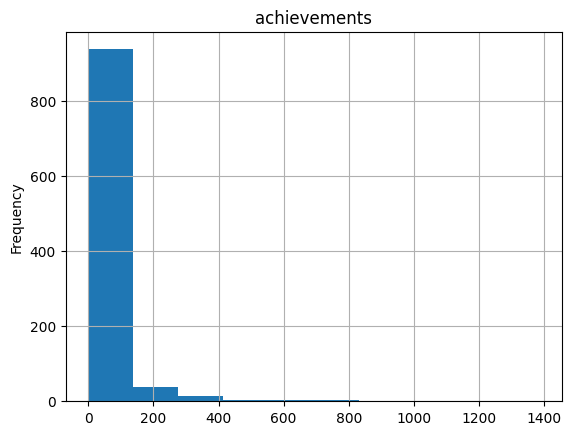

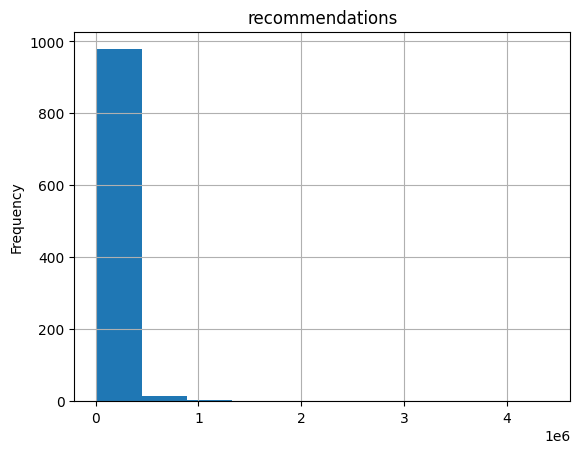

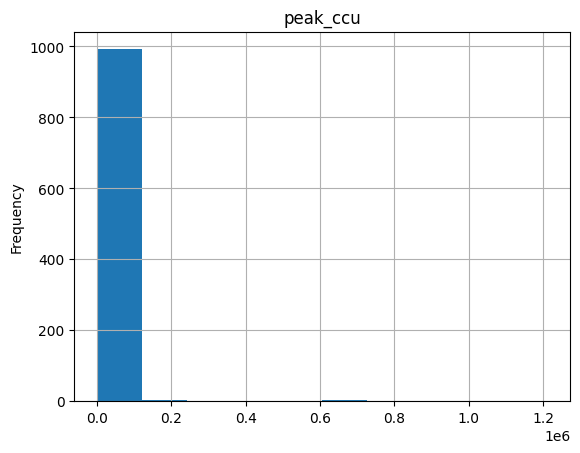

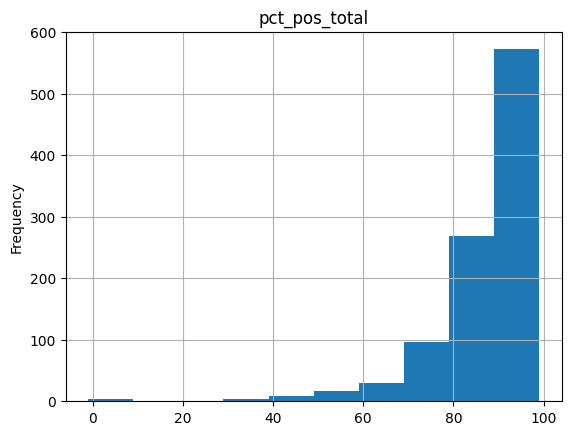

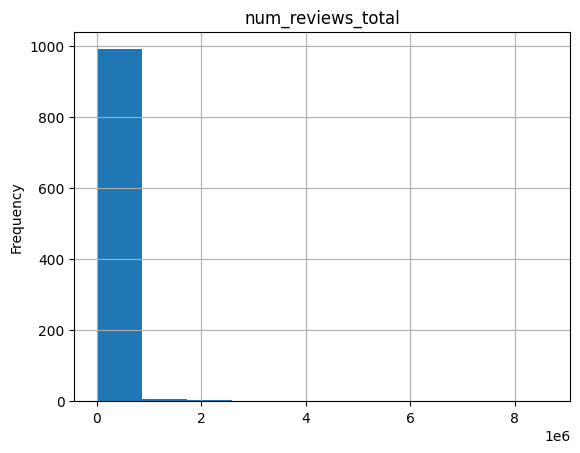

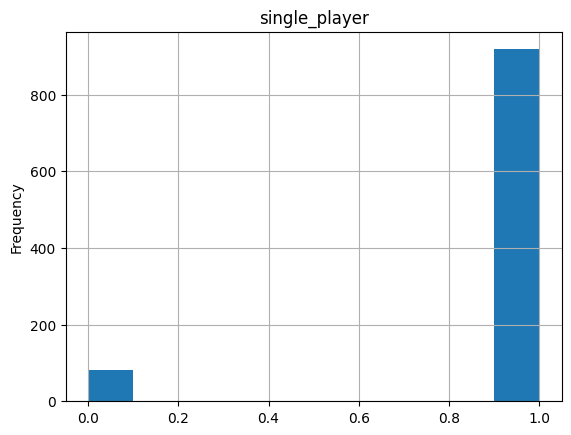

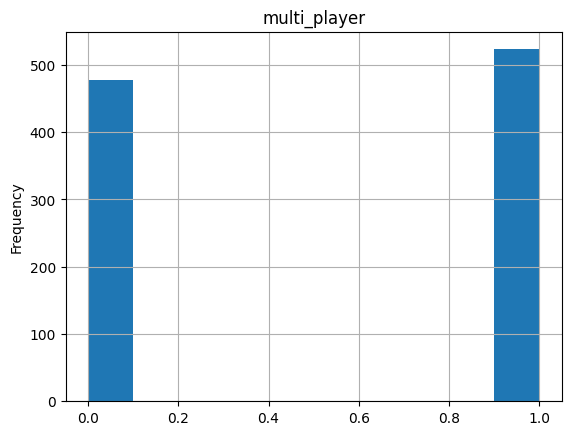

In [148]:
# Distribution des données
# For the columns with numbers, we can plot the histograms
# features=['release_year', 'required_age', 'price', 'metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']
# extract column names (numeric only to plot histograms)  
features = df.select_dtypes(include='number').columns.tolist()
print("Features:", features)

#histogrammes
for x in features:
  plt.figure()
  df[x].plot.hist()
  plt.title(x)
  plt.grid()
#même en affichant les données sous l'échelle logarithmique, on observe déjà des pics au niveau de 0 pour les données manquantes(le dataset n'est pas complet)

# #covariance & correlation
# df2=df[['metacritic_score','achievements','recommendations','positive','negative','median_playtime_forever','peak_ccu','num_reviews_total']]
# df2.corr() 
# #on observe qu'il y a qlq redondances dans notre jeux de données, les catégories recommendations, positive et num_reviews_total ont une correlation au dessus de 0.9.

# df.plot.scatter(x='peak_ccu',y='metacritic_score')
# df.plot.scatter(x='metacritic_score',y='recommendations')
# df.plot.scatter(x='positive',y='median_playtime_forever')
# #en testant qlq combinaisons de catégories en x et y (en évitant de prendre des catégories trop redondantes), 
# # on observe que les données ne se regroupe pas bien, se répartissant plus selon l'absence de données que formant des clusters cohérents

# df.sort_values("negative", ascending=False).head(1)


In [149]:
#we search for how much features are missing

missing = df.eq(0).sum()
lenght= len(df)
print(missing)
print("lenght total du data set =",lenght)

#on observe que beaucoup de données sont manquante sur ce dataset, en particulier sur les petits jeux qui représentent la majorité des sorties steam.

name                   0
release_year           0
required_age         758
price                 45
dlc_count            285
metacritic_score     470
achievements         112
recommendations        0
peak_ccu              16
pct_pos_total          0
num_reviews_total      0
single_player         82
multi_player         477
dtype: int64
lenght total du data set = 1000


In [150]:
# Supprimer l'outlier pour tester
# df = df[df['name'] != 'Counter-Strike 2']

In [151]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

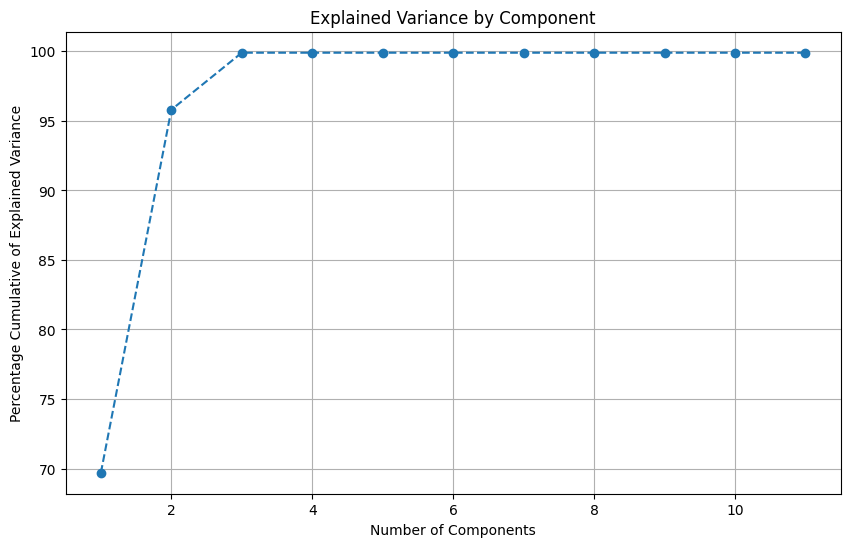

,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player
0,Counter-Strike 2,2012,0,0.00,1,0,1,4401572,1212356,86,8632939,0,1
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,117698,87,1803832,1,1
1,PUBG: BATTLEGROUNDS,2017,0,0.00,0,0,37,1732007,616738,59,2513842,0,1
4,Tom Clancy's Rainbow Six® Siege,2015,17,3.99,9,0,0,1165929,89916,84,1168020,1,1
6,Terraria,2011,0,9.99,2,83,115,1098792,30516,97,1102434,1,1


In [152]:
from sklearn.preprocessing import Normalizer

data = df.drop(columns=['name', 'release_year'])

df_normalized = Normalizer().fit_transform(data.values)
# print(df_normalized.shape)
# print(df_normalized)
pca = PCA()
pca.fit(df_normalized)
per_var = np.round(pca.explained_variance_ratio_*100, decimals = 1)

plt.figure(figsize = (10,6))
plt.plot(range(1, len(per_var)+1), per_var.cumsum(), marker = "o", linestyle = "--")
plt.grid()
plt.ylabel("Percentage Cumulative of Explained Variance")
plt.xlabel("Number of Components")
plt.title("Explained Variance by Component")
plt.show()

df.head()

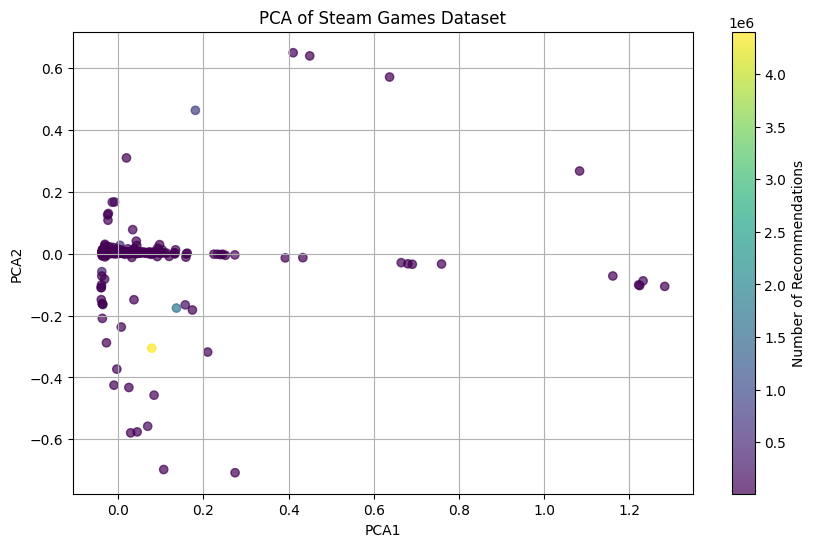

PCA1    1000
PCA2    1000
dtype: int64

In [ ]:
pca = PCA(n_components = 2)
pca.fit(df_normalized)

data_pca = pca.transform(df_normalized)
df_reduced = pd.DataFrame(data_pca, columns = ['PCA1', 'PCA2'])
df_reduced.insert(0, "name", df['name'])

## Visualisation 2D 
plt.figure(figsize=(10,6))
# for i, txt in enumerate(df_reduced['name']):
#     plt.annotate(txt, (df_reduced['PCA1'][i], df_reduced['PCA2'][i]), fontsize=8, alpha=0.6)
# Coloring by recommendations
scatter = plt.scatter(df_reduced['PCA1'], df_reduced['PCA2'], c=df['recommendations'], cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Number of Recommendations')
plt.title("PCA of Steam Games Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid()
plt.show()

# Visualisation 3D
# from mpl_toolkits.mplot3d import Axes3D
# fig = plt.figure(figsize=(10,7))
# ax = fig.add_subplot(111, projection='3d')
# scatter = ax.scatter(df_reduced['PCA1'], df_reduced['PCA2'], data_pca[:,2], c=df['recommendations'], cmap='viridis', alpha=0.7)
# cbar = plt.colorbar(scatter)
# cbar.set_label('Number of Recommendations')
# ax.set_title("3D PCA of Steam Games Dataset")
# ax.set_xlabel("PCA1")
# ax.set_ylabel("PCA2")
# ax.set_zlabel("PCA3")
# plt.show()
# Count the line of df_normalized

df_reduced.count()

In [154]:
feature_names = data.columns

# Matrice des loadings (composantes)
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=feature_names
)

print(loadings)

                        PC1       PC2
required_age      -0.000114  0.000048
price             -0.000079  0.000943
dlc_count         -0.000087  0.000140
metacritic_score  -0.001505  0.000957
achievements      -0.000967  0.000736
recommendations   -0.347769  0.772098
peak_ccu           0.831312 -0.008400
pct_pos_total     -0.002227  0.001352
num_reviews_total -0.433555 -0.635444
single_player     -0.000022  0.000018
multi_player      -0.000001 -0.000002


[[ 0.07836599 -0.30537869]
 [ 0.00158592  0.00532699]
 [ 0.13643838 -0.17578685]
 ...
 [-0.0370273   0.00599516]
 [-0.01920726  0.00521397]
 [-0.03884998 -0.07237094]]


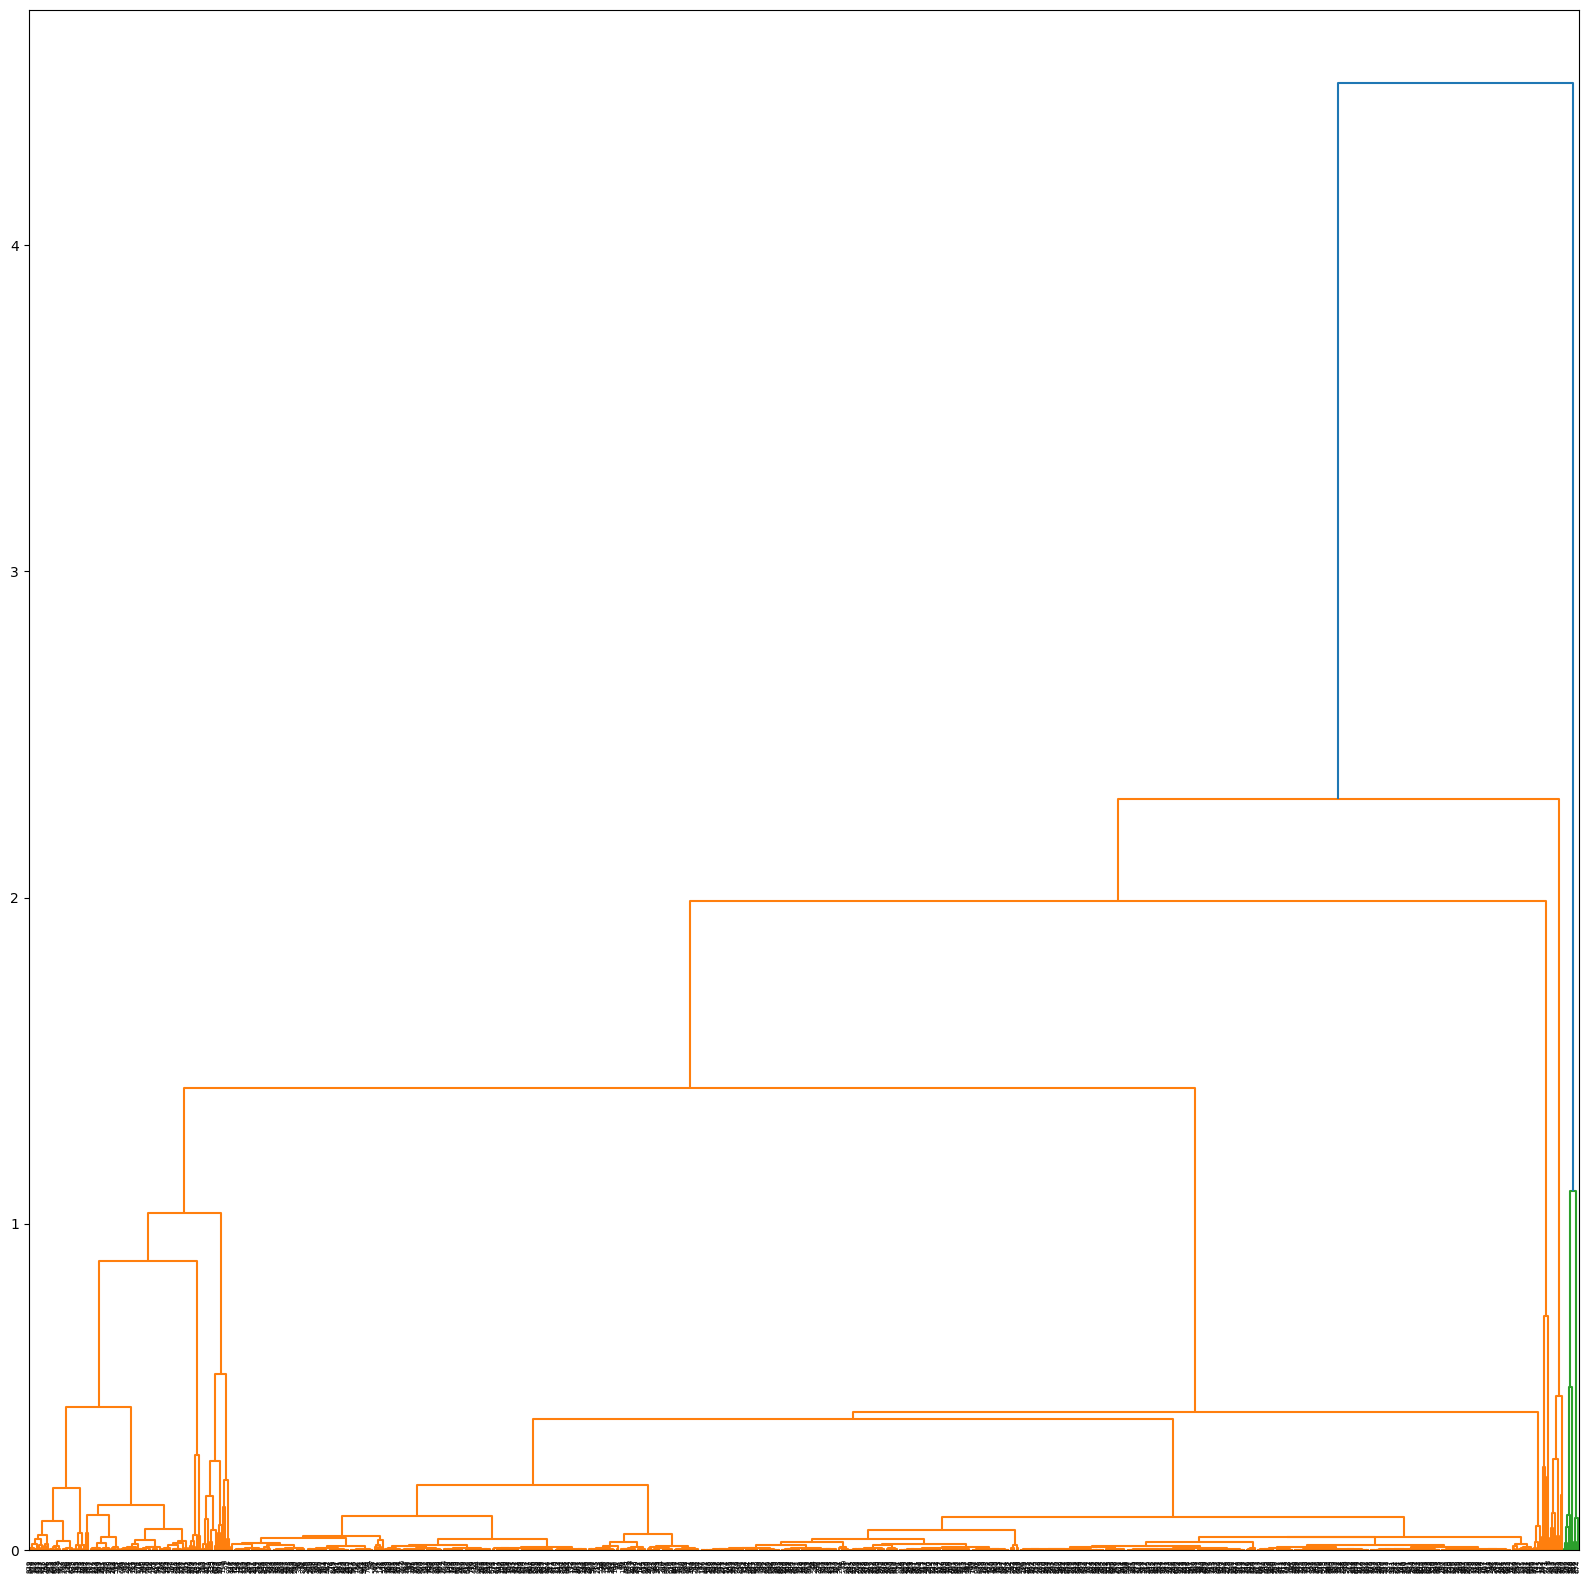

In [155]:
import scipy.cluster.hierarchy as shc

print(data_pca)

linked_mat = shc.linkage(data_pca, "ward")

plt.figure(figsize=(20,20))
shc.dendrogram(linked_mat,
              orientation='top',
              distance_sort='descending',
              show_leaf_counts=True)
plt.show()

In [156]:
import time
from sklearn import cluster
# set distance_threshold(0 ensures we compute the full tree)
tps1 = time.time()
model = cluster.AgglomerativeClustering(distance_threshold = 0.15 , \
    linkage = "single" , n_clusters = None)
model = model.fit(data_pca)
tps2 = time.time()

labels = model.labels_
nb_clusters = model.n_clusters_
leaves = model.n_leaves_
print("nb clusters =", nb_clusters ,", nb feuilles =", leaves , "runtime =", round (( tps2 - tps1) * 1000 , 2) ," ms")

nb clusters = 8 , nb feuilles = 1000 runtime = 8.55  ms


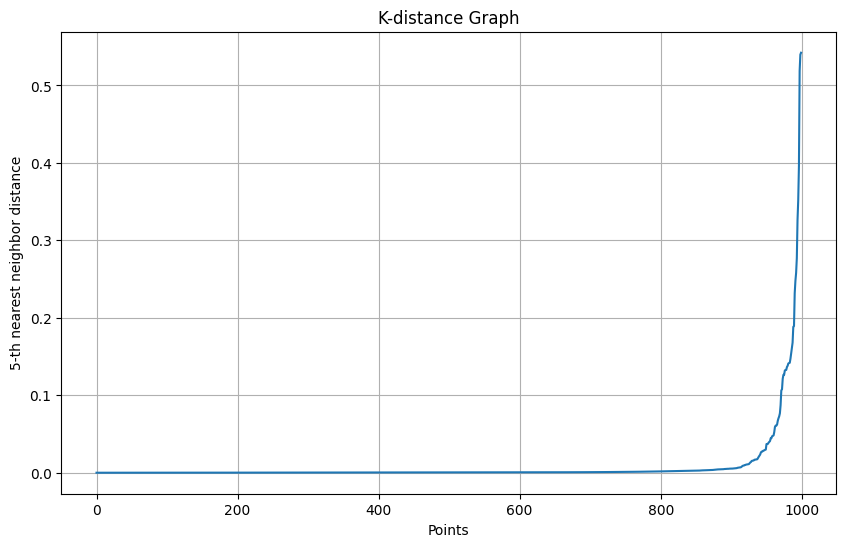

In [157]:
from sklearn.neighbors import NearestNeighbors
# Function to plot k-distance graph
def plot_k_distance_graph(X, k):
    neigh = NearestNeighbors(n_neighbors=k)
    neigh.fit(X)
    distances, _ = neigh.kneighbors(X)
    distances = np.sort(distances[:, k-1])
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.xlabel('Points')
    plt.ylabel(f'{k}-th nearest neighbor distance')
    plt.title('K-distance Graph')
    plt.grid()
    plt.show()
# Plot k-distance graph
plot_k_distance_graph(data_pca, k=5)

In [158]:
# Essaie avec DBSCAN
# from sklearn.cluster import DBSCAN
# tps1 = time.time()
# dbscan_model = DBSCAN(eps=0.09, min_samples=30)
# dbscan_model.fit(data_pca)
# tps2 = time.time()

# labels = dbscan_model.labels_

In [159]:

df_clustered = df.copy()
df_clustered['Cluster'] = labels
cluster_counts = df_clustered['Cluster'].value_counts().sort_index()
print(cluster_counts)
nb_clusters = cluster_counts.shape[0]
df_clustered.head(100)

## Plot les clusters selon les composants PCA
## Visualisation 2D 
plt.figure(figsize=(10,6))
for i, txt in enumerate(df_reduced['name']):
    plt.annotate(txt, (df_reduced['PCA1'][i], df_reduced['PCA2'][i]), fontsize=8, alpha=0.6)
# Coloring by cluster
scatter = plt.scatter(df_reduced['PCA1'], df_reduced['PCA2'], c=df_clustered['Cluster'], cmap='viridis', alpha=0.7)
cbar = plt.colorbar(scatter)
cbar.set_label('Cluster Label')
plt.title("PCA of Steam Games Dataset")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid()
plt.show()

# Visualisation 3D
# from mpl_toolkits.mplot3d import Axes3D
# fig = plt.figure(figsize=(10,7))
# ax = fig.add_subplot(111, projection='3d')
# # Tourner l'angle de vue 3D
# # ax.view_init(elev=20., azim=0)

# scatter = ax.scatter(df_reduced['PCA1'], df_reduced['PCA2'], data_pca[:,2], c=df_clustered['Cluster'], cmap='viridis', alpha=0.7)
# # Legend for clusters
# cbar = plt.colorbar(scatter)
# cbar.set_label('Cluster Label')

# ax.set_title("3D PCA of Steam Games Dataset")
# ax.set_xlabel("PCA1")
# ax.set_ylabel("PCA2")
# ax.set_zlabel("PCA3")
# plt.show()
df_clustered.sort_values(by='Cluster', ascending=False).head(20)


Cluster
0    985
1      4
2      5
3      1
4      1
5      1
6      2
7      1
Name: count, dtype: int64


KeyError: 'name'

<Figure size 1000x600 with 0 Axes>

In [ ]:
# import seaborn as sns

# for feature in features:
#     # --- 2. Create the Plot ---
#     plt.figure(figsize=(10, 6))

#     # The Box Plot Command
#     sns.boxplot(x='Cluster', y=feature, data=df_clustered, hue='Cluster', palette='viridis', legend=False)

#     # Labeling
#     plt.title(f'{feature} distribution by Cluster')
#     plt.xlabel('Cluster (0-4)')
#     plt.ylabel(feature)
#     plt.grid()
#     plt.show()

In [ ]:
# Sort and display top games per cluster (cluster 5 à 1)
# df_clustered.sort_values(by='Cluster', ascending=False).head(20)
df_clustered.head(20)
# print(f"Top 10 recommended games in Noise Cluster:")

,name,release_year,required_age,price,dlc_count,metacritic_score,achievements,recommendations,peak_ccu,pct_pos_total,num_reviews_total,single_player,multi_player,Cluster
0,Counter-Strike 2,2012,0,0.00,1,0,1,4401572,1212356,86,8632939,0,1,0
3,Grand Theft Auto V Legacy,2015,17,0.00,0,96,77,1803063,117698,87,1803832,1,1,0
1,PUBG: BATTLEGROUNDS,2017,0,0.00,0,0,37,1732007,616738,59,2513842,0,1,0
4,Tom Clancy's Rainbow Six® Siege,2015,17,3.99,9,0,0,1165929,89916,84,1168020,1,1,0
6,Terraria,2011,0,9.99,2,83,115,1098792,30516,97,1102434,1,1,0
7,Rust,2018,0,39.99,4,69,92,992825,200902,87,993856,0,1,0
8,Garry's Mod,2006,0,5.99,0,0,29,984713,32384,96,985010,1,1,0
10,Black Myth: Wukong,2024,13,59.99,2,0,81,825294,35990,96,825621,1,0,0
56729,Wallpaper Engine,2018,0,4.99,1,0,17,809225,120461,98,239047,0,0,4
11,The Witcher 3: Wild Hunt,2015,17,39.99,22,93,78,761658,15129,96,751939,1,0,0


In [ ]:
## Afficher les 10 jeux les plus recommandés par cluster
# top_games = df_clustered[df_clustered['Cluster'] == -1].sort_values(by='recommendations', ascending=False).head(20)
# print(f"Top 10 recommended games in Noise Cluster:")
# print(top_games[['name', 'recommendations', 'pct_pos_total', 'price']])
# print("\n")
# for cluster_num in range(nb_clusters):
#     top_games = df_clustered[df_clustered['Cluster'] == cluster_num].sort_values(by='recommendations', ascending=False).head(20)
#     print(f"Top 10 recommended games in Cluster {cluster_num}:")
#     print(top_games[['name', 'recommendations', 'pct_pos_total', 'price', 'metacritic_score', 'multi_player', 'single_player']])
#     print("\n")